# Notebook 120: シーケンスとは何か ― 時間の次元へ

## What is a Sequence? — Into the Time Dimension

---

### このノートブックの位置づけ

**Unit 8「シーケンスモデリング」** の導入として、静的データと系列データの違いを理解し、従来のMLPによるシーケンス処理の限界を体験します。

### 学習目標

1. **静的データと系列データ** の本質的な違いを説明できる
2. **スライディングウィンドウMLP** を実装し、その限界を体験する
3. **状態（state）** の概念がなぜ必要かを直感的に理解する
4. **パラメータ爆発** の問題を数値的に確認できる

### 前提知識

- Notebook 70-76（ニューラルエンジンの深部）の内容
- NumPyによる行列演算の基礎

⏱️ **推定学習時間**: 60-90分
📊 **難易度**: ★★☆☆☆（初級）
🎓 **カテゴリ**: 基礎

---

## 目次

1. [静的データ vs 系列データ](#1-静的データ-vs-系列データ)
2. [サイン波予測タスク](#2-サイン波予測タスク)
3. [スライディングウィンドウMLP](#3-スライディングウィンドウmlp)
4. [ウィンドウ幅の限界](#4-ウィンドウ幅の限界)
5. [パラメータ爆発の問題](#5-パラメータ爆発の問題)
6. [「状態」という解決策](#6-状態という解決策)
7. [まとめ](#7-まとめ)
8. [自己評価クイズ](#8-自己評価クイズ)

In [1]:
# ============================================================
# 環境セットアップ
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import japanize_matplotlib # 日本語化
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

np.random.seed(42)

print("環境セットアップ完了")

環境セットアップ完了


---

## 1. 静的データ vs 系列データ

### 🤔 データに「順番」があるとは？

これまで扱ってきたデータ（例：アイリスの花びらの長さ、住宅の広さ）は **静的データ** でした。
各サンプルは独立しており、順番を入れ替えても意味は変わりません。

しかし、世の中のデータの多くは **時間的な順序** を持っています：

| 静的データ（順番なし） | 系列データ（順番あり） |
|----------------------|---------------------|
| 花びらの長さ 3.5cm | 株価: 100→105→103→108 |
| 部屋の面積 70m² | 気温: 15°→18°→22°→20° |
| 画像のピクセル値 | テキスト: "今日は良い天気" |
| 患者の検査値 | 心電図の波形 |

**系列データの本質**：過去の値が未来に影響する。つまり **文脈（コンテキスト）** が重要。

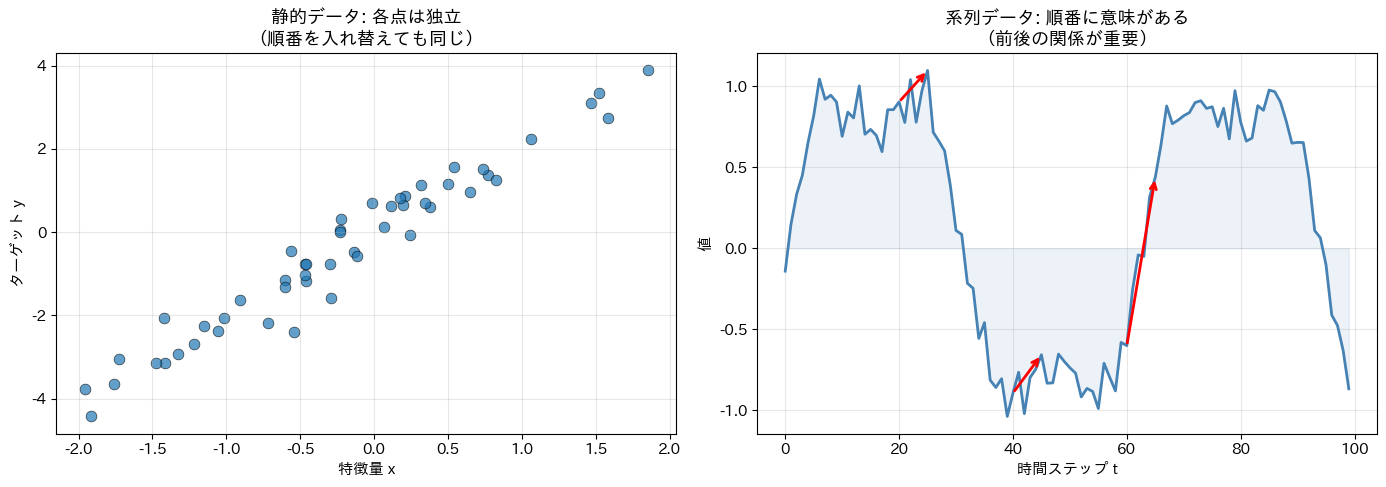

【ポイント】
静的データ: 各サンプルは独立（i.i.d.仮定）
系列データ: 過去の値が未来を予測するヒントになる


In [2]:
# ============================================================
# 静的データ vs 系列データの可視化
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 静的データ（散布図）
np.random.seed(42)
x_static = np.random.randn(50)
y_static = 2 * x_static + np.random.randn(50) * 0.5
axes[0].scatter(x_static, y_static, alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('特徴量 x')
axes[0].set_ylabel('ターゲット y')
axes[0].set_title('静的データ: 各点は独立\n（順番を入れ替えても同じ）', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 右: 系列データ（時系列）
t = np.arange(100)
y_seq = np.sin(0.1 * t) + 0.3 * np.sin(0.3 * t) + np.random.randn(100) * 0.1
axes[1].plot(t, y_seq, linewidth=2, color='steelblue')
axes[1].fill_between(t, y_seq, alpha=0.1, color='steelblue')
axes[1].set_xlabel('時間ステップ t')
axes[1].set_ylabel('値')
axes[1].set_title('系列データ: 順番に意味がある\n（前後の関係が重要）', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 系列データの依存関係を矢印で示す
for i in [20, 40, 60]:
    axes[1].annotate('', xy=(i+5, y_seq[i+5]), xytext=(i, y_seq[i]),
                     arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.tight_layout()
plt.show()

print("【ポイント】")
print("静的データ: 各サンプルは独立（i.i.d.仮定）")
print("系列データ: 過去の値が未来を予測するヒントになる")

---

## 2. サイン波予測タスク

### タスク定義

シンプルなサイン波を使って、「次の値を予測する」タスクを設定します。

$$y(t) = \sin\left(\frac{2\pi t}{50}\right)$$

**目標**: $y(t-k), \ldots, y(t-1)$ から $y(t)$ を予測する

これは最もシンプルなシーケンス予測問題です。人間なら簡単にパターンを見抜けますが、MLPにとってはどうでしょうか？

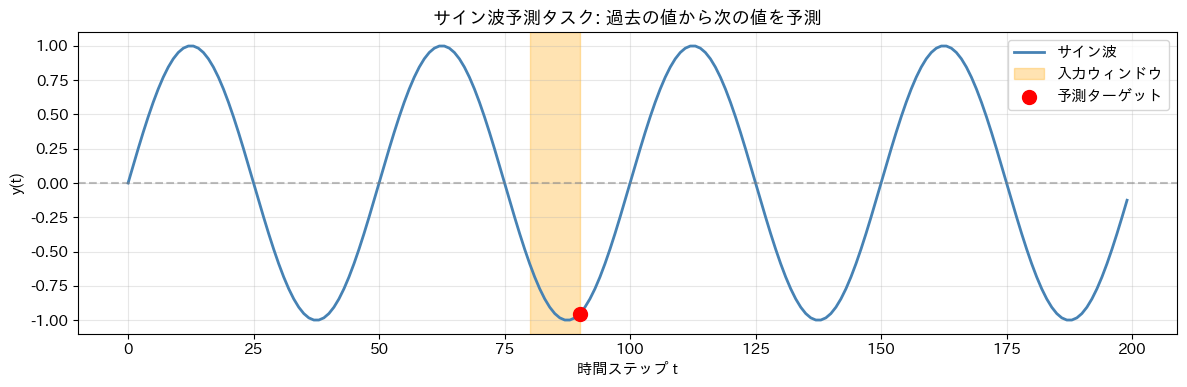

データ点数: 500
周期: 50ステップ
タスク: 過去のウィンドウから次の値を予測


In [3]:
# ============================================================
# サイン波データの生成
# ============================================================

def generate_sine_data(n_points=500, period=50):
    """サイン波データを生成"""
    t = np.arange(n_points)
    y = np.sin(2 * np.pi * t / period)
    return t, y

t, y = generate_sine_data()

# 可視化
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t[:200], y[:200], linewidth=2, color='steelblue', label='サイン波')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 予測タスクを示す
window_start = 80
window_size = 10
ax.axvspan(window_start, window_start + window_size, alpha=0.3, color='orange', label='入力ウィンドウ')
ax.scatter(window_start + window_size, y[window_start + window_size], 
           color='red', s=100, zorder=5, label='予測ターゲット')

ax.set_xlabel('時間ステップ t')
ax.set_ylabel('y(t)')
ax.set_title('サイン波予測タスク: 過去の値から次の値を予測', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"データ点数: {len(t)}")
print(f"周期: 50ステップ")
print(f"タスク: 過去のウィンドウから次の値を予測")

In [4]:
# ============================================================
# スライディングウィンドウでデータセットを作成
# ============================================================

def create_windowed_dataset(y, window_size):
    """
    スライディングウィンドウでデータセットを作成
    
    Args:
        y: 時系列データ (1D array)
        window_size: ウィンドウ幅
    
    Returns:
        X: 入力 (N, window_size)
        targets: ターゲット (N,)
    """
    X, targets = [], []
    for i in range(len(y) - window_size):
        X.append(y[i:i + window_size])
        targets.append(y[i + window_size])
    return np.array(X), np.array(targets)

# ウィンドウサイズ10でデータセット作成
window_size = 10
X, targets = create_windowed_dataset(y, window_size)

# 訓練/テスト分割（時系列なので先頭を訓練、末尾をテスト）
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
t_train, t_test = targets[:split], targets[split:]

print(f"ウィンドウサイズ: {window_size}")
print(f"訓練データ: X={X_train.shape}, t={t_train.shape}")
print(f"テストデータ: X={X_test.shape}, t={t_test.shape}")
print(f"\n入力例（最初のウィンドウ）:")
print(f"  X[0] = {X_train[0].round(3)}")
print(f"  t[0] = {t_train[0]:.3f}")

ウィンドウサイズ: 10
訓練データ: X=(392, 10), t=(392,)
テストデータ: X=(98, 10), t=(98,)

入力例（最初のウィンドウ）:
  X[0] = [0.    0.125 0.249 0.368 0.482 0.588 0.685 0.771 0.844 0.905]
  t[0] = 0.951


---

## 3. スライディングウィンドウMLP

### 🤔 単純なアプローチ：ウィンドウを特徴量にする

最も素朴なアプローチは、ウィンドウ内の値を **特徴量ベクトル** としてMLPに入力することです。

```
入力: [y(t-10), y(t-9), ..., y(t-1)]  ← 10次元のベクトル
  ↓
MLP（全結合層 + 活性化関数）
  ↓
出力: ŷ(t)  ← 予測値
```

これは本質的に、系列データを **静的データとして扱う** ことを意味します。

In [5]:
# ============================================================
# シンプルなMLPの実装（Notebook 75の復習）
# ============================================================

class SimpleMLP:
    """
    2層MLP（全結合層のみ）
    
    構造: input → hidden → output
    """
    
    def __init__(self, input_dim, hidden_dim, output_dim=1):
        # Xavier初期化
        scale1 = np.sqrt(2.0 / (input_dim + hidden_dim))
        scale2 = np.sqrt(2.0 / (hidden_dim + output_dim))
        
        self.W1 = np.random.randn(input_dim, hidden_dim) * scale1
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, output_dim) * scale2
        self.b2 = np.zeros(output_dim)
    
    def forward(self, X):
        """順伝播"""
        self.X = X
        self.z1 = X @ self.W1 + self.b1
        self.h1 = np.tanh(self.z1)
        self.z2 = self.h1 @ self.W2 + self.b2
        return self.z2
    
    def backward(self, dout):
        """逆伝播"""
        # 出力層
        self.dW2 = self.h1.T @ dout
        self.db2 = np.sum(dout, axis=0)
        
        # 隠れ層
        dh1 = dout @ self.W2.T
        dz1 = dh1 * (1 - self.h1 ** 2)  # tanh'(x) = 1 - tanh²(x)
        self.dW1 = self.X.T @ dz1
        self.db1 = np.sum(dz1, axis=0)
    
    def update(self, lr=0.01):
        """パラメータ更新"""
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2
    
    def count_params(self):
        """パラメータ数を計算"""
        return (self.W1.size + self.b1.size + 
                self.W2.size + self.b2.size)


print("SimpleMLP クラスを定義しました")

SimpleMLP クラスを定義しました


In [6]:
# ============================================================
# MLPでサイン波を予測
# ============================================================

def train_mlp(X_train, t_train, X_test, t_test, hidden_dim=32, 
              n_epochs=200, lr=0.01, verbose=True):
    """MLPを訓練"""
    input_dim = X_train.shape[1]
    
    np.random.seed(42)
    model = SimpleMLP(input_dim, hidden_dim)
    
    train_losses = []
    test_losses = []
    
    # ターゲットの形状を合わせる
    t_train_2d = t_train.reshape(-1, 1)
    t_test_2d = t_test.reshape(-1, 1)
    
    for epoch in range(n_epochs):
        # 順伝播
        pred = model.forward(X_train)
        loss = np.mean((pred - t_train_2d) ** 2)
        
        # 逆伝播
        dout = 2 * (pred - t_train_2d) / len(t_train)
        model.backward(dout)
        model.update(lr=lr)
        
        # テスト損失
        test_pred = model.forward(X_test)
        test_loss = np.mean((test_pred - t_test_2d) ** 2)
        
        # 訓練データで再度forward（テストでキャッシュが上書きされるため）
        model.forward(X_train)
        
        train_losses.append(loss)
        test_losses.append(test_loss)
        
        if verbose and (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d}: Train Loss = {loss:.6f}, Test Loss = {test_loss:.6f}")
    
    return model, train_losses, test_losses

# ウィンドウサイズ10で訓練
print("=" * 60)
print("ウィンドウサイズ = 10 での MLP 訓練")
print("=" * 60)
model_w10, train_losses_w10, test_losses_w10 = train_mlp(
    X_train, t_train, X_test, t_test, hidden_dim=32, n_epochs=300, lr=0.01
)

print(f"\nパラメータ数: {model_w10.count_params()}")

ウィンドウサイズ = 10 での MLP 訓練
Epoch  50: Train Loss = 0.029278, Test Loss = 0.027366
Epoch 100: Train Loss = 0.002240, Test Loss = 0.002057
Epoch 150: Train Loss = 0.000978, Test Loss = 0.000947
Epoch 200: Train Loss = 0.000868, Test Loss = 0.000858
Epoch 250: Train Loss = 0.000810, Test Loss = 0.000805
Epoch 300: Train Loss = 0.000758, Test Loss = 0.000754

パラメータ数: 385


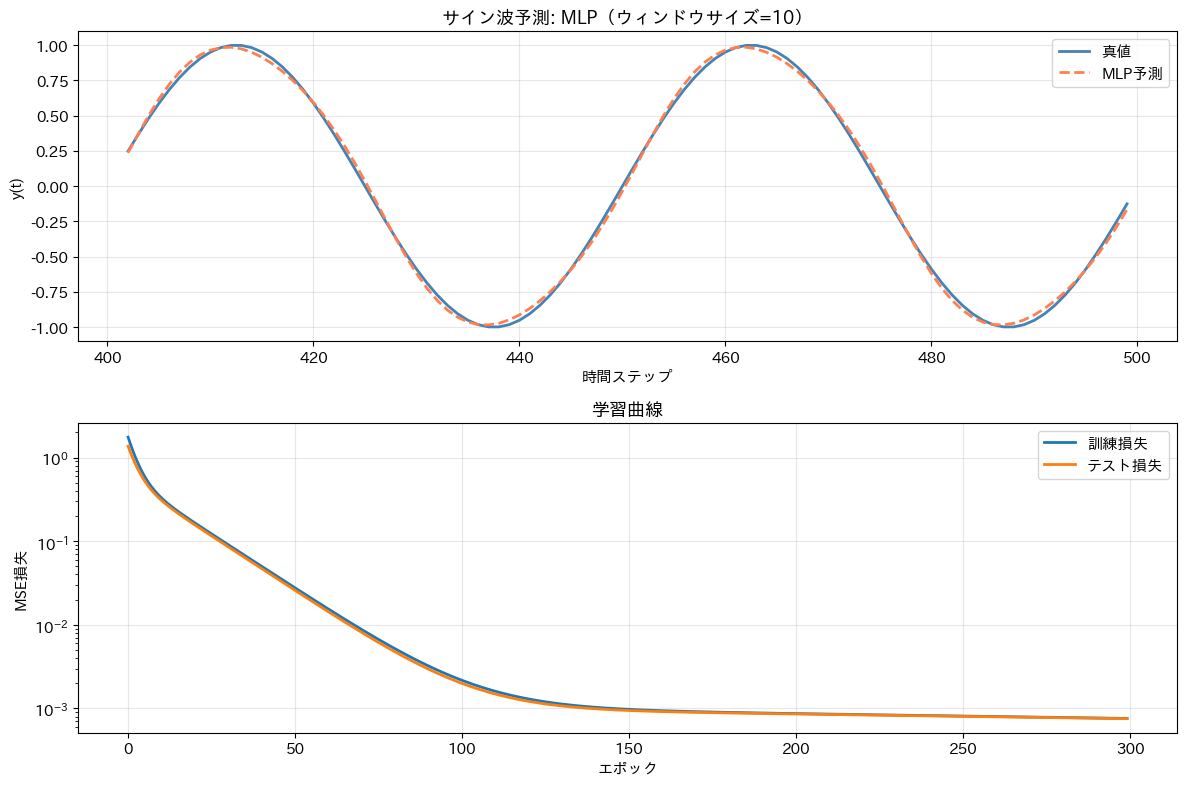

テストMSE: 0.000754

【観察】
単純なサイン波なら、MLPでもある程度予測できる。
しかし、これはウィンドウ内のパターンを丸暗記しているだけ...


In [7]:
# ============================================================
# MLPの予測結果を可視化
# ============================================================

# テストデータでの予測
test_pred = model_w10.forward(X_test).flatten()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 予測 vs 真値
test_range = np.arange(split + window_size, split + window_size + len(t_test))
axes[0].plot(test_range, t_test, label='真値', linewidth=2, color='steelblue')
axes[0].plot(test_range, test_pred, label='MLP予測', linewidth=2, 
             color='coral', linestyle='--')
axes[0].set_xlabel('時間ステップ')
axes[0].set_ylabel('y(t)')
axes[0].set_title('サイン波予測: MLP（ウィンドウサイズ=10）', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 学習曲線
axes[1].plot(train_losses_w10, label='訓練損失', linewidth=2)
axes[1].plot(test_losses_w10, label='テスト損失', linewidth=2)
axes[1].set_xlabel('エポック')
axes[1].set_ylabel('MSE損失')
axes[1].set_title('学習曲線', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

final_mse = np.mean((test_pred - t_test) ** 2)
print(f"テストMSE: {final_mse:.6f}")
print(f"\n【観察】")
print(f"単純なサイン波なら、MLPでもある程度予測できる。")
print(f"しかし、これはウィンドウ内のパターンを丸暗記しているだけ...")

---

## 4. ウィンドウ幅の限界

### 🤔 ウィンドウを大きくすれば解決する？

「より多くの過去情報を使えば、もっと正確に予測できるのでは？」

この直感は半分正しく、半分間違っています。試してみましょう。

In [8]:
# ============================================================
# 複雑な信号でウィンドウサイズを変化させる実験
# ============================================================

def generate_complex_signal(n_points=500):
    """
    複数の周波数を含む複雑な信号
    長期依存性を持つ：低周波成分の予測には長い履歴が必要
    """
    t = np.arange(n_points)
    # 短周期 + 長周期 + ノイズ
    y = (np.sin(2 * np.pi * t / 20) +        # 短周期（周期20）
         0.5 * np.sin(2 * np.pi * t / 100) +  # 長周期（周期100）
         0.1 * np.random.randn(n_points))      # ノイズ
    return t, y

t_complex, y_complex = generate_complex_signal()

# 異なるウィンドウサイズで実験
window_sizes = [5, 10, 25, 50]
results = {}

for ws in window_sizes:
    X_c, t_c = create_windowed_dataset(y_complex, ws)
    split_c = int(len(X_c) * 0.8)
    X_tr, X_te = X_c[:split_c], X_c[split_c:]
    t_tr, t_te = t_c[:split_c], t_c[split_c:]
    
    model, train_l, test_l = train_mlp(
        X_tr, t_tr, X_te, t_te, 
        hidden_dim=32, n_epochs=300, lr=0.01, verbose=False
    )
    
    pred = model.forward(X_te).flatten()
    mse = np.mean((pred - t_te) ** 2)
    results[ws] = {
        'mse': mse, 'pred': pred, 'true': t_te,
        'params': model.count_params(), 'test_losses': test_l
    }
    print(f"ウィンドウサイズ {ws:3d}: MSE = {mse:.6f}, パラメータ数 = {model.count_params()}")

ウィンドウサイズ   5: MSE = 0.031768, パラメータ数 = 225
ウィンドウサイズ  10: MSE = 0.023235, パラメータ数 = 385
ウィンドウサイズ  25: MSE = 0.021926, パラメータ数 = 865
ウィンドウサイズ  50: MSE = 0.015152, パラメータ数 = 1665


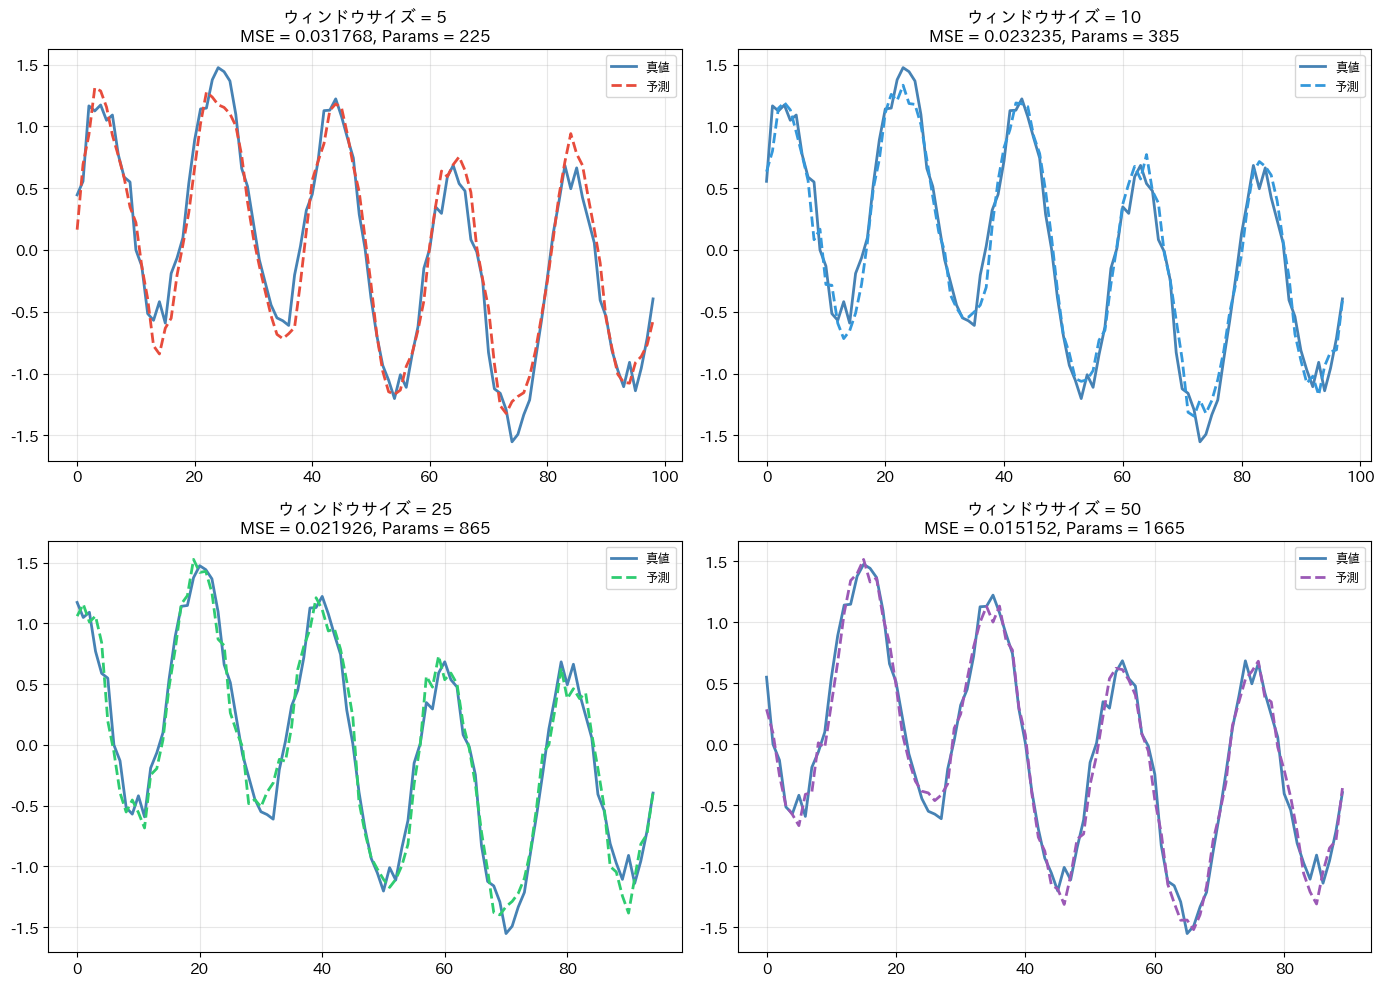

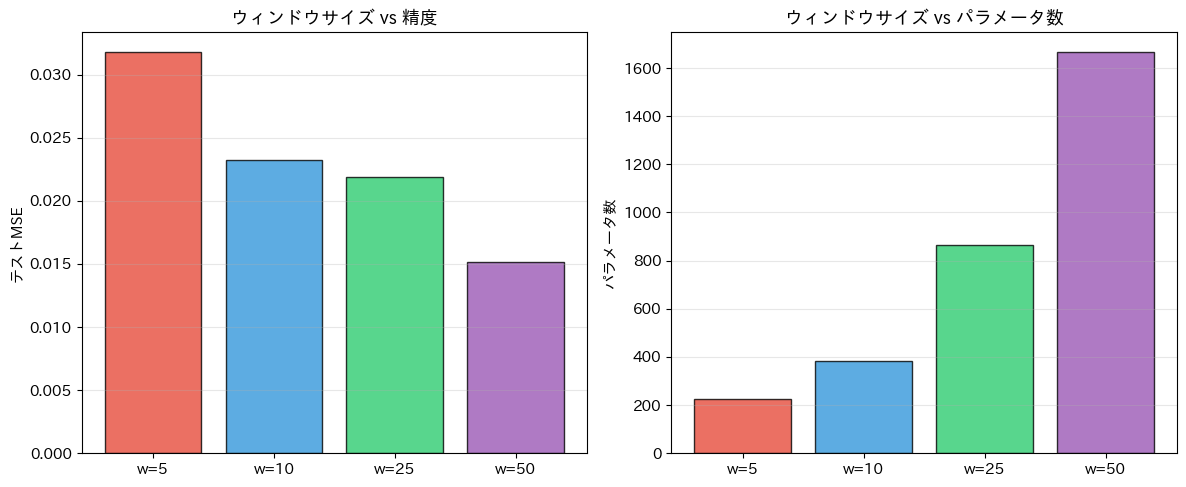

【観察】
1. ウィンドウを大きくすると長周期成分も捉えやすい
2. しかし、パラメータ数が線形に増加する
3. ウィンドウ外の依存関係は永遠に捉えられない


In [9]:
# ============================================================
# ウィンドウサイズごとの結果を可視化
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for ax, (ws, color) in zip(axes.flat, zip(window_sizes, colors)):
    r = results[ws]
    n_show = min(100, len(r['true']))
    ax.plot(r['true'][:n_show], label='真値', linewidth=2, color='steelblue')
    ax.plot(r['pred'][:n_show], label='予測', linewidth=2, color=color, linestyle='--')
    ax.set_title(f'ウィンドウサイズ = {ws}\nMSE = {r["mse"]:.6f}, Params = {r["params"]}',
                fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# MSE vs ウィンドウサイズ vs パラメータ数
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ws_list = list(results.keys())
mse_list = [results[ws]['mse'] for ws in ws_list]
param_list = [results[ws]['params'] for ws in ws_list]

axes[0].bar(range(len(ws_list)), mse_list, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(len(ws_list)))
axes[0].set_xticklabels([f'w={ws}' for ws in ws_list])
axes[0].set_ylabel('テストMSE')
axes[0].set_title('ウィンドウサイズ vs 精度', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(len(ws_list)), param_list, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_xticks(range(len(ws_list)))
axes[1].set_xticklabels([f'w={ws}' for ws in ws_list])
axes[1].set_ylabel('パラメータ数')
axes[1].set_title('ウィンドウサイズ vs パラメータ数', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("【観察】")
print("1. ウィンドウを大きくすると長周期成分も捉えやすい")
print("2. しかし、パラメータ数が線形に増加する")
print("3. ウィンドウ外の依存関係は永遠に捉えられない")

---

## 5. パラメータ爆発の問題

### 📊 MLPの根本的な問題

スライディングウィンドウMLPには、以下の構造的な問題があります：

1. **パラメータ爆発**: ウィンドウ幅 $w$ を2倍にすると、入力層の重みも2倍
2. **固定長制限**: 入力の長さが固定（可変長の系列を扱えない）
3. **位置の硬直性**: $y(t-5)$ と $y(t-3)$ を別の重みで処理（パターンの再利用なし）
4. **長期依存の断絶**: ウィンドウ外の情報は完全に失われる

これらの問題を数値で確認しましょう。

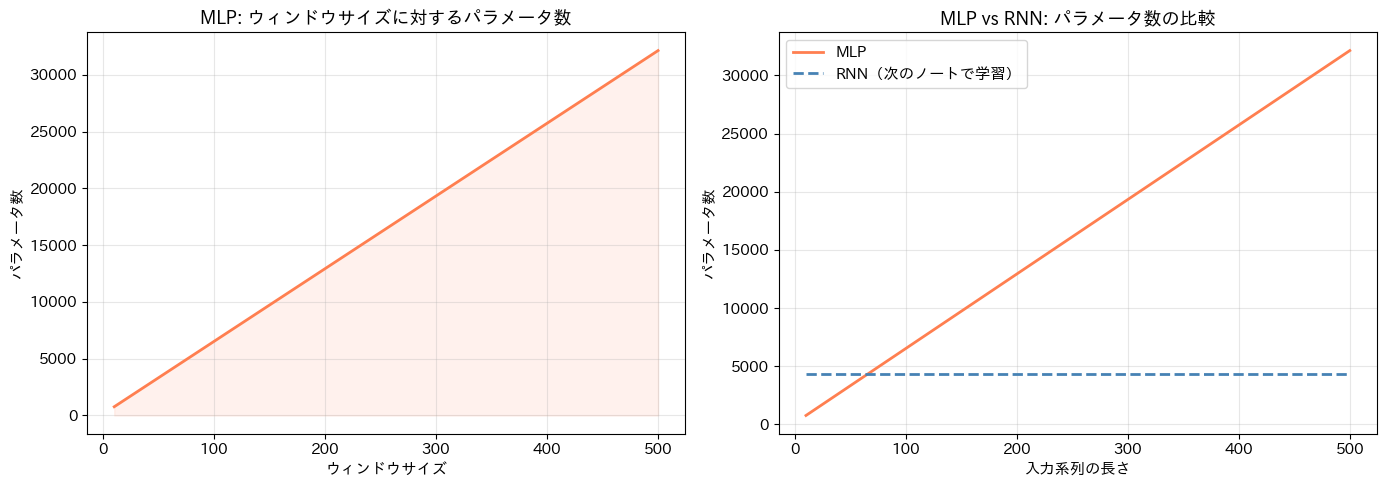

【ポイント】
ウィンドウ  10: パラメータ数 = 769
ウィンドウ 100: パラメータ数 = 6529
ウィンドウ 500: パラメータ数 = 32129

RNN（固定）: パラメータ数 = 4353

→ MLPはO(w)でパラメータが増加するが、RNNはO(1)で一定！


In [10]:
# ============================================================
# パラメータ爆発の可視化
# ============================================================

hidden_dim = 64

window_sizes_range = np.arange(10, 510, 10)
param_counts = []

for ws in window_sizes_range:
    # MLP: input(ws) → hidden(64) → output(1)
    n_params = ws * hidden_dim + hidden_dim + hidden_dim * 1 + 1
    param_counts.append(n_params)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# パラメータ数の増加
axes[0].plot(window_sizes_range, param_counts, linewidth=2, color='coral')
axes[0].fill_between(window_sizes_range, param_counts, alpha=0.1, color='coral')
axes[0].set_xlabel('ウィンドウサイズ')
axes[0].set_ylabel('パラメータ数')
axes[0].set_title('MLP: ウィンドウサイズに対するパラメータ数', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# RNN（次のノートで学ぶ）との比較（予告）
# RNNのパラメータ数はウィンドウサイズに依存しない
rnn_params = [hidden_dim * hidden_dim + hidden_dim + 1 * hidden_dim + hidden_dim + hidden_dim * 1 + 1] * len(window_sizes_range)

axes[1].plot(window_sizes_range, param_counts, linewidth=2, label='MLP', color='coral')
axes[1].plot(window_sizes_range, rnn_params, linewidth=2, label='RNN（次のノートで学習）', 
             color='steelblue', linestyle='--')
axes[1].set_xlabel('入力系列の長さ')
axes[1].set_ylabel('パラメータ数')
axes[1].set_title('MLP vs RNN: パラメータ数の比較', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("【ポイント】")
print(f"ウィンドウ  10: パラメータ数 = {10 * hidden_dim + hidden_dim + hidden_dim + 1}")
print(f"ウィンドウ 100: パラメータ数 = {100 * hidden_dim + hidden_dim + hidden_dim + 1}")
print(f"ウィンドウ 500: パラメータ数 = {500 * hidden_dim + hidden_dim + hidden_dim + 1}")
print(f"\nRNN（固定）: パラメータ数 = {rnn_params[0]}")
print(f"\n→ MLPはO(w)でパラメータが増加するが、RNNはO(1)で一定！")

---

## 6. 「状態」という解決策

### 💡 発想の転換：全ての履歴を覚えなくても良い

MLPの問題を整理すると、本質的な課題は：

> **過去の情報を「ウィンドウ内の生データ」として保持している**

もし、過去の情報を **圧縮して持ち運べる** としたらどうでしょう？

```
MLPアプローチ:
  [y(t-10), y(t-9), ..., y(t-1)] → 予測
  （ウィンドウの生データを全て入力）

状態ベースのアプローチ:
  h(t-1) + y(t) → h(t) → 予測
  （過去の要約 + 新しい入力 → 更新された要約）
```

これが **リカレントニューラルネットワーク（RNN）** の基本的なアイデアです！

### 📊 状態の概念図

```
時刻 t=1:  x₁ → [ 処理 ] → h₁（x₁の要約）
時刻 t=2:  x₂ + h₁ → [ 処理 ] → h₂（x₁,x₂の要約）
時刻 t=3:  x₃ + h₂ → [ 処理 ] → h₃（x₁,x₂,x₃の要約）
...
時刻 t=T:  xₜ + hₜ₋₁ → [ 処理 ] → hₜ（全履歴の要約）→ 予測
```

**キーポイント**：
- 状態 $h_t$ は過去の全情報の圧縮表現
- パラメータ数は入力長に依存しない
- 可変長の系列を自然に処理できる

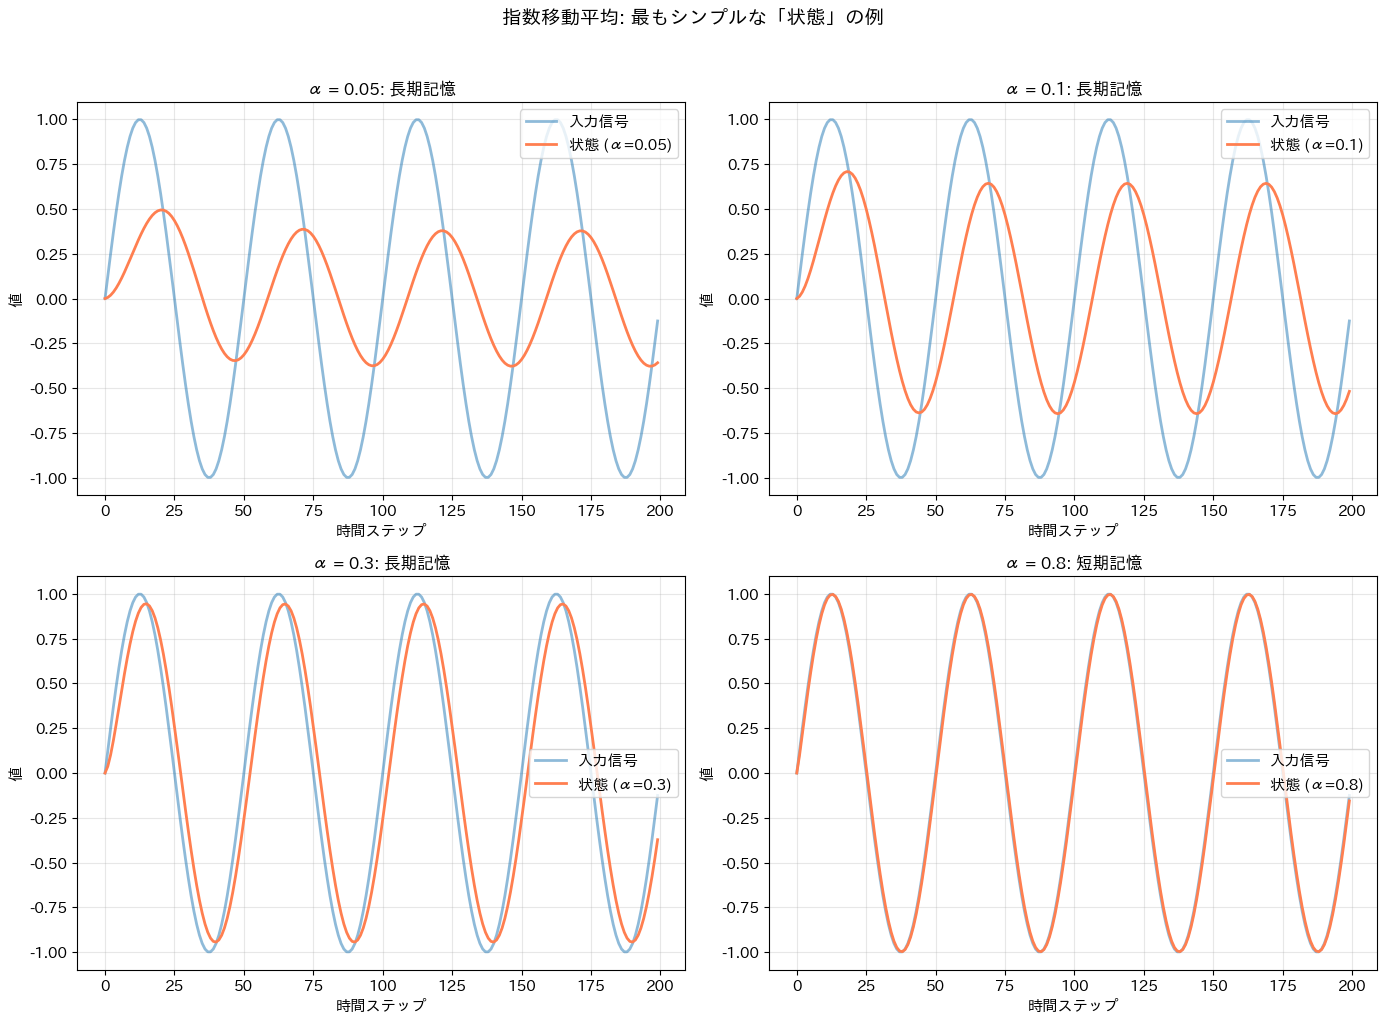

【ポイント】
α が小さい → 過去を長く覚える（長期記憶）
α が大きい → 最近の値に敏感（短期記憶）

RNNはこの α をデータから学習する！
さらに、非線形変換を加えて、複雑なパターンを記憶できる。


In [11]:
# ============================================================
# 「状態」の概念を簡単な例で体験
# ============================================================

def simple_state_machine(sequence):
    """
    最もシンプルな状態マシン：
    状態 = 過去の値の指数移動平均
    
    h(t) = 0.9 * h(t-1) + 0.1 * x(t)
    
    これだけでも「過去の記憶」を持つ！
    """
    states = []
    h = 0  # 初期状態
    alpha = 0.1
    
    for x in sequence:
        h = (1 - alpha) * h + alpha * x
        states.append(h)
    
    return np.array(states)

# サイン波に対する指数移動平均
t_demo = np.arange(200)
y_demo = np.sin(2 * np.pi * t_demo / 50)

# 異なるalphaでの状態
alphas = [0.05, 0.1, 0.3, 0.8]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, alpha in zip(axes.flat, alphas):
    states = []
    h = 0
    for x in y_demo:
        h = (1 - alpha) * h + alpha * x
        states.append(h)
    states = np.array(states)
    
    ax.plot(t_demo, y_demo, label='入力信号', linewidth=2, alpha=0.5)
    ax.plot(t_demo, states, label=f'状態 (α={alpha})', linewidth=2, color='coral')
    ax.set_xlabel('時間ステップ')
    ax.set_ylabel('値')
    ax.set_title(f'α = {alpha}: {"短期記憶" if alpha > 0.5 else "長期記憶"}',
                fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('指数移動平均: 最もシンプルな「状態」の例', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("【ポイント】")
print("α が小さい → 過去を長く覚える（長期記憶）")
print("α が大きい → 最近の値に敏感（短期記憶）")
print("")
print("RNNはこの α をデータから学習する！")
print("さらに、非線形変換を加えて、複雑なパターンを記憶できる。")

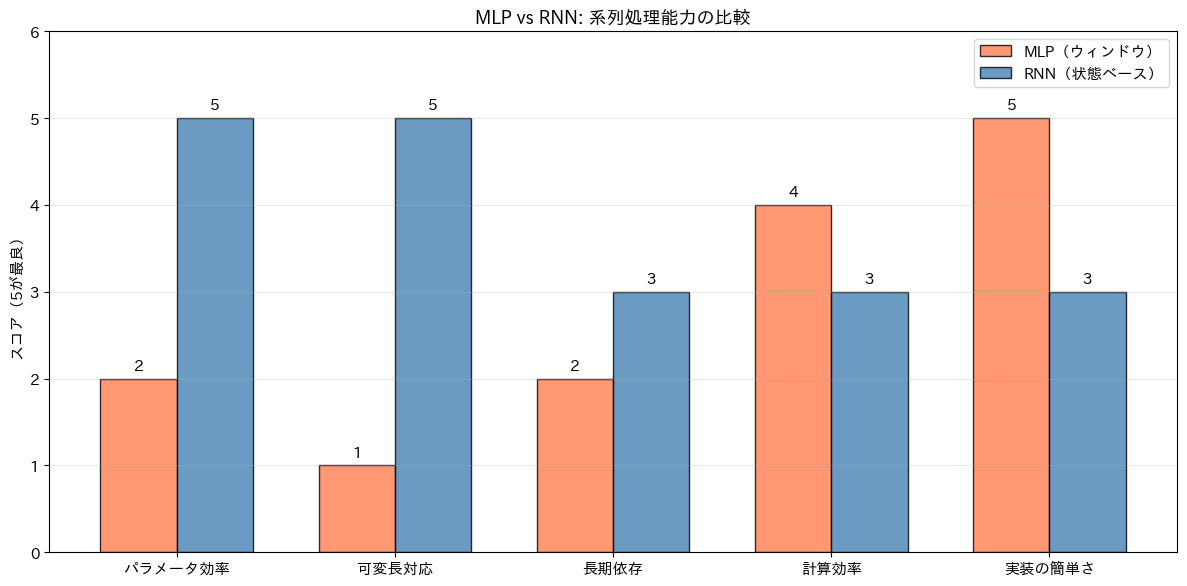

【まとめ】
MLPは実装が簡単だが、系列処理には根本的な限界がある
RNN（次のノートで学習）は「状態」により、これらの限界を克服する


In [12]:
# ============================================================
# MLP vs 状態ベースアプローチの比較まとめ
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

categories = ['パラメータ効率', '可変長対応', '長期依存', '計算効率', '実装の簡単さ']
mlp_scores = [2, 1, 2, 4, 5]
rnn_scores = [5, 5, 3, 3, 3]

x_pos = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x_pos - width/2, mlp_scores, width, label='MLP（ウィンドウ）', 
               color='coral', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x_pos + width/2, rnn_scores, width, label='RNN（状態ベース）', 
               color='steelblue', alpha=0.8, edgecolor='black')

ax.set_ylabel('スコア（5が最良）')
ax.set_title('MLP vs RNN: 系列処理能力の比較', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 6)
ax.grid(True, alpha=0.3, axis='y')

# スコアをバーの上に表示
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("【まとめ】")
print("MLPは実装が簡単だが、系列処理には根本的な限界がある")
print("RNN（次のノートで学習）は「状態」により、これらの限界を克服する")

---

## 7. まとめ

### 🎯 このノートブックで学んだこと

**静的データ vs 系列データ**
- ✓ 系列データは順序に意味がある
- ✓ 過去の値が未来を予測するヒントになる

**スライディングウィンドウMLPの限界**
- ✓ パラメータ数がウィンドウサイズに比例して増加する
- ✓ 固定長入力しか扱えない
- ✓ ウィンドウ外の長期依存関係を捉えられない
- ✓ 時間位置ごとに異なる重みを使うため非効率

**状態の概念**
- ✓ 過去の情報を圧縮して持ち運ぶアイデア
- ✓ パラメータ数が系列長に依存しない
- ✓ 可変長の系列を自然に処理できる

### 📊 チートシート

| 観点 | MLP（ウィンドウ） | RNN（状態ベース） |
|------|------------------|------------------|
| 入力形式 | 固定長ベクトル | 1ステップずつ |
| パラメータ数 | O(w × h) | O(h²) |
| 可変長対応 | ✗ | ✓ |
| 重み共有 | なし | 時間方向で共有 |
| 長期依存 | ウィンドウ内のみ | 理論上は無限 |

### ⚠️ よくある間違い

❌ 「ウィンドウを大きくすればMLPでも長期依存を捉えられる」
✅ パラメータ爆発と過学習のリスクが増大する。状態ベースのアプローチが根本的な解決策。

❌ 「系列データも普通のMLPで十分」
✅ 単純なパターンならMLPでも可能だが、可変長・長期依存・効率性の面でRNNが優位。

### ✅ 学習チェックリスト

- [ ] 静的データと系列データの違いを説明できる
- [ ] スライディングウィンドウMLPを実装できる
- [ ] ウィンドウ幅を変えたときのトレードオフを説明できる
- [ ] 「状態」がなぜ必要かを直感的に説明できる

---

**次のステップ**: Notebook 121 で、**バニラRNN** を実装し、状態を持つネットワークの仕組みを理解します！

---

## 8. 自己評価クイズ

学習内容を確認しましょう！

### Q1: スライディングウィンドウMLPの最大の欠点は何ですか？

<details>
<summary>💡 答えを見る</summary>

**答え**: ウィンドウ外の長期依存関係を捉えられないこと。

パラメータ数の増加も問題ですが、最も根本的な問題は、ウィンドウの外にある過去の情報が完全に失われることです。いくらウィンドウを広げても、その外側の依存関係は永遠に見えません。

</details>

---

### Q2: RNNの「状態」とは何を表していますか？

<details>
<summary>💡 答えを見る</summary>

**答え**: 過去の全入力情報の圧縮表現（要約）。

状態ベクトル $h_t$ は、時刻1からtまでの全ての入力を要約した固定長のベクトルです。新しい入力が来るたびに更新され、過去の文脈を保持します。

</details>

---

### Q3: MLPのパラメータ数が O(w × h) なのに対し、RNNが O(h²) で済む理由は？

<details>
<summary>💡 答えを見る</summary>

**答え**: RNNは時間方向で重みを共有するため。

MLPはウィンドウの各位置に対して別々の重みを持ちますが、RNNは同じ重み行列を全ての時刻で再利用します。これにより、パラメータ数が入力長に依存しません。

</details>

---

### Q4: 指数移動平均の α を大きくすると、状態はどう変化しますか？

<details>
<summary>💡 答えを見る</summary>

**答え**: より最近の入力に敏感になり、過去の情報を早く忘れる（短期記憶になる）。

$h_t = (1-\alpha) \cdot h_{t-1} + \alpha \cdot x_t$ なので、αが大きいと新しい入力 $x_t$ の影響が大きくなり、過去の状態 $h_{t-1}$ の影響が小さくなります。

</details>

---

## 参考文献

1. Elman, J. L. (1990). Finding structure in time. *Cognitive Science*, 14(2), 179-211.
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Chapter 10. MIT Press.